In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [4]:
from src.util import read_video_frames, display_image, draw_bounding_box, draw_3d_bounding_boxes, render_scene, get_character_placeholder, show_mask
from src.operations2d import get_2d_bounding_boxes, bounding_boxes_to_image_chunks, get_masks_from_image_chunks

final text_encoder_type: bert-base-uncased


Loading config ov-seg/configs/ovseg_swinB_vitL_demo.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[03/05 12:58:50 detectron2]: Rank of current process: 0. World size: 1
[03/05 12:58:50 detectron2]: Environment info:
-------------------------------  -------------------------------------------------------------------------------------------
sys.platform                     linux
Python                           3.8.20 (default, Oct  3 2024, 15:24:27) [GCC 11.2.0]
numpy                            1.24.4
detectron2                       0.6 @/home/max/miniconda3/envs/instruct360/lib/python3.8/site-packages/detectron2
Compiler                         GCC 13.3
CUDA compiler                    not available
DETECTRON2_ENV_MODULE            <not set>
PyTorch                          2.4.1+cu121 @/home/max/miniconda3/envs/instruct360/lib/python3.8/site-packages/torch
PyTorch debug build              False
torch._C._GLIBCXX_USE_CXX11_ABI  False
GPU available                    No: torch.cuda.is_available() == False
Pillow                           10.4.0
torchvision                      0.19

Using cache found in /home/max/.cache/torch/hub/facebookresearch_dinov2_main


final text_encoder_type: bert-base-uncased
[03/05 12:58:53 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from checkpoints/ovmono3d_lift.pth ...
[03/05 12:58:53 fvcore.common.checkpoint]: [Checkpointer] Loading from checkpoints/ovmono3d_lift.pth ...
WARNING [03/05 12:58:53 fvcore.common.checkpoint]: Some model parameters or buffers are not found in the checkpoint:
roi_heads.groundingdino_model.backbone.0.layers.0.blocks.0.attn.proj.{bias, weight}
roi_heads.groundingdino_model.backbone.0.layers.0.blocks.0.attn.qkv.{bias, weight}
roi_heads.groundingdino_model.backbone.0.layers.0.blocks.0.attn.{relative_position_bias_table, relative_position_index}
roi_heads.groundingdino_model.backbone.0.layers.0.blocks.0.mlp.fc1.{bias, weight}
roi_heads.groundingdino_model.backbone.0.layers.0.blocks.0.mlp.fc2.{bias, weight}
roi_heads.groundingdino_model.backbone.0.layers.0.blocks.0.norm1.{bias, weight}
roi_heads.groundingdino_model.backbone.0.layers.0.blocks.0.norm2.{bias, weight}


In [5]:
video_path = "vids/hallway_horizontal.mp4"
frame_index = 120

object_class = "cupboard"

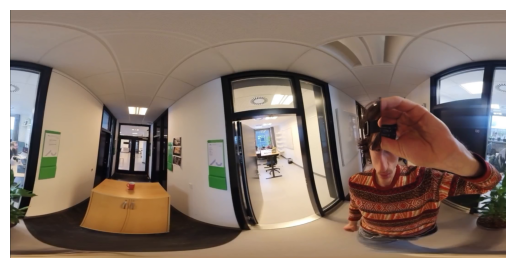

In [6]:
input_frame = read_video_frames(video_path)[frame_index]

display_image(input_frame)

# Single Class

Get panorama 2dbb and get image chunk

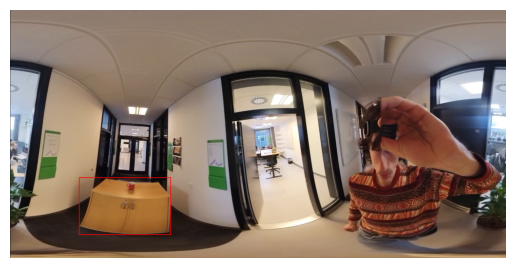

In [7]:
bounding_boxes = get_2d_bounding_boxes(input_frame, object_class)
frame_with_boxes = input_frame.copy()
for box in bounding_boxes:
    frame_with_boxes = draw_bounding_box(frame_with_boxes, box)

display_image(frame_with_boxes)

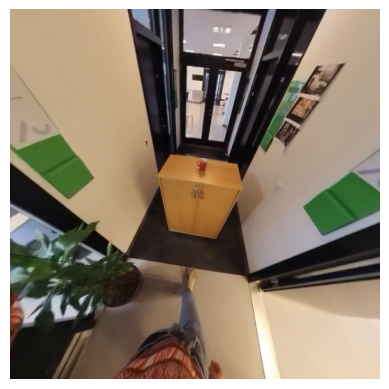

In [9]:
image_chunks = bounding_boxes_to_image_chunks(input_frame, bounding_boxes, orientation="horizontal")
display_image(image_chunks[0].image)

Get image chunk bb

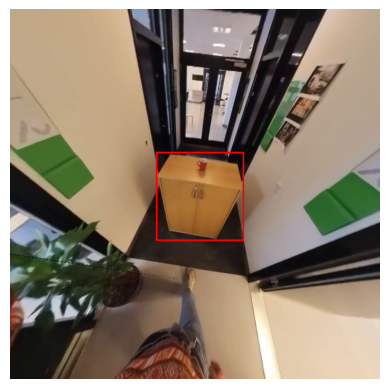

In [10]:
chunk_bbs = get_2d_bounding_boxes(image_chunks[0].image, object_class)
chunk_frame_with_boxes = image_chunks[0].image.copy()
for bb in chunk_bbs:
    chunk_frame_with_boxes = draw_bounding_box(chunk_frame_with_boxes, bb)
display_image(chunk_frame_with_boxes)

Get object masks

In [20]:
masks = get_masks_from_image_chunks(image_chunks, prompt=object_class)

In [ ]:
display_image(masks[0])

IndexError: list index out of range

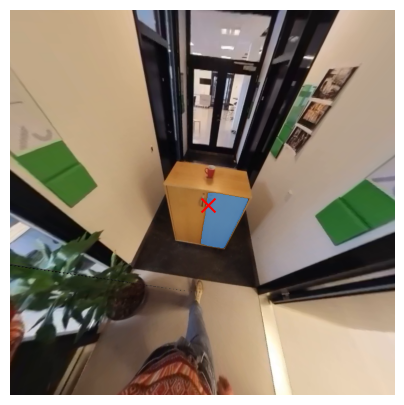

In [36]:
import matplotlib.pyplot as plt
import numpy as np

bounding_box = chunk_bbs[0]
h, w, _ = image_chunks[0].image.shape
box_center_pixel = np.array([[int(bounding_box[0] * w), int(bounding_box[1] * h)]])

plt.figure(figsize=(5, 5))
plt.axis('off')
plt.imshow(image_chunks[0].image)

plt.scatter(box_center_pixel[0][0], box_center_pixel[0][1], c='red', s=100, marker='x')
show_mask(masks[0], plt.gca(), random_color=False)